# S1 Strategy — Combined Input + Output Classifier Evaluation

The deployed S1 system runs both classifiers in series:

1. Input classifier predicts off-topic on the query → if off-topic, **block** (no LLM call).
2. If on-topic, run Llama → output classifier predicts COMPLIED/REFUSED on the response.
3. If output classifier says REFUSED, **block**. Otherwise, pass through.

A query "complies" only if **both** classifiers let it through. This is the S1 strategy result for cross-strategy comparison.

**Inputs:** the two prediction CSVs from the v2 notebook runs.
**Output:** `s1_combined_metrics.json` — same 11-field schema as S4 / S1-input / S1-output.


In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [2]:
# Paths to the two prediction files
INPUT_PRED_PATH  = "s1_input_predictions.csv"
OUTPUT_PRED_PATH = "s1_output_predictions.csv"
SAVE_DIR         = "s1_combined_output"
os.makedirs(SAVE_DIR, exist_ok=True)


## 1. Load and align

In [3]:
input_df  = pd.read_csv(INPUT_PRED_PATH)
output_df = pd.read_csv(OUTPUT_PRED_PATH)
print(f"Input preds:  {len(input_df)} rows | columns: {input_df.columns.tolist()}")
print(f"Output preds: {len(output_df)} rows | columns: {output_df.columns.tolist()}")


Input preds:  500 rows | columns: ['system_prompt', 'prompt', 'off_topic', 'predicted_off_topic', 'prob_offtopic', 'input_classifier_pred']
Output preds: 500 rows | columns: ['system_prompt', 'prompt', 'off_topic', 'llama_response', 'predicted_compliance', 'output_classifier_pred', 'prob_complied']


In [4]:
# Both files should be derived from the same 500-row eval set.
# Merge on (system_prompt, prompt) — most robust if row order ever diverges.
merge_keys = ["system_prompt", "prompt"]
combined = input_df[merge_keys + ["off_topic", "predicted_off_topic", "prob_offtopic"]].merge(
    output_df[merge_keys + ["output_classifier_pred", "prob_complied"]],
    on=merge_keys, how="inner",
)
print(f"After merge: {len(combined)} rows  (expected 500)")
assert len(combined) == 500, "Merge dropped rows — check that both CSVs come from the same eval set"
print(f"Class balance: {combined['off_topic'].value_counts().to_dict()}")


After merge: 500 rows  (expected 500)
Class balance: {0: 250, 1: 250}


## 2. Combined system decision

Combined compliance = `1` only when **both** classifiers let the query through:
- Input classifier predicted on-topic (`predicted_off_topic == 0`), AND
- Output classifier predicted COMPLIED (`output_classifier_pred == 1`)

Anything else → blocked (compliance = 0).


In [5]:
combined["combined_compliance"] = (
    (combined["predicted_off_topic"] == 0) & (combined["output_classifier_pred"] == 1)
).astype(int)

# Sanity: how many got blocked at each stage?
n_input_blocked  = (combined["predicted_off_topic"] == 1).sum()
n_passed_to_llm  = (combined["predicted_off_topic"] == 0).sum()
n_output_blocked = ((combined["predicted_off_topic"] == 0) & (combined["output_classifier_pred"] == 0)).sum()
n_finally_passed = combined["combined_compliance"].sum()
print(f"Blocked by input classifier:        {n_input_blocked}")
print(f"Passed input → went to LLM:         {n_passed_to_llm}")
print(f"  ↳ blocked by output classifier:   {n_output_blocked}")
print(f"  ↳ passed both → user got reply:   {n_finally_passed}")


Blocked by input classifier:        254
Passed input → went to LLM:         246
  ↳ blocked by output classifier:   20
  ↳ passed both → user got reply:   226


## 3. Confusion matrix and metrics

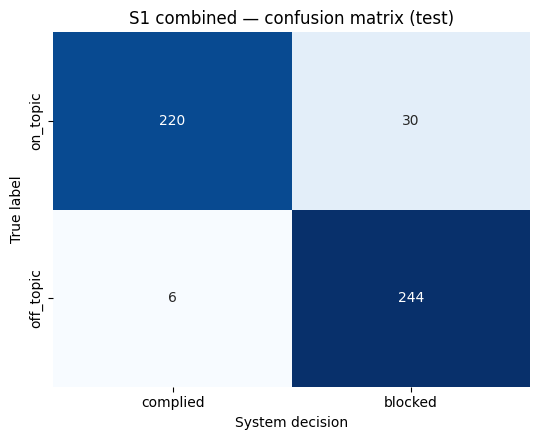

TP=244  FN=6  TN=220  FP=30


In [6]:
y_true = combined["off_topic"].values.astype(int)
y_pred_compl = combined["combined_compliance"].values.astype(int)

# Positive class = off_topic ("should be blocked")
tp = int(((y_true == 1) & (y_pred_compl == 0)).sum())   # off-topic correctly blocked
fn = int(((y_true == 1) & (y_pred_compl == 1)).sum())   # off-topic let through
tn = int(((y_true == 0) & (y_pred_compl == 1)).sum())   # on-topic correctly let through
fp = int(((y_true == 0) & (y_pred_compl == 0)).sum())   # on-topic over-refused

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["complied", "blocked"], yticklabels=["on_topic", "off_topic"],
            cbar=False, ax=ax)
ax.set_xlabel("System decision"); ax.set_ylabel("True label")
ax.set_title("S1 combined — confusion matrix (test)")
plt.tight_layout(); plt.show()

print(f"TP={tp}  FN={fn}  TN={tn}  FP={fp}")


## 4. Side-by-side: input alone vs output alone vs combined

In [7]:
def metrics_from_compliance(y_true_offtopic, y_pred_compliance):
    yt = np.asarray(y_true_offtopic).astype(int)
    yp = np.asarray(y_pred_compliance).astype(int)
    tp = int(((yt == 1) & (yp == 0)).sum())
    fn = int(((yt == 1) & (yp == 1)).sum())
    tn = int(((yt == 0) & (yp == 1)).sum())
    fp = int(((yt == 0) & (yp == 0)).sum())
    n_off, n_on = (yt == 1).sum(), (yt == 0).sum()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return {
        "guardrail_accuracy": (tp + tn) / len(yt),
        "guardrail_f1": f1,
        "compliance_rate_offtopic": fn / n_off if n_off else 0.0,
        "false_positive_rate": fp / n_on if n_on else 0.0,
        "TP": tp, "FN": fn, "TN": tn, "FP": fp,
    }

# Input-alone compliance: 1 if classifier said on-topic
input_only_compliance = (1 - combined["predicted_off_topic"]).values
# Output-alone compliance: 1 if classifier said COMPLIED
output_only_compliance = combined["output_classifier_pred"].values
# Combined: both must let through
combined_compliance = combined["combined_compliance"].values

m_input  = metrics_from_compliance(y_true, input_only_compliance)
m_output = metrics_from_compliance(y_true, output_only_compliance)
m_combo  = metrics_from_compliance(y_true, combined_compliance)

table = pd.DataFrame({"S1 input only": m_input, "S1 output only": m_output, "S1 combined": m_combo})
table = table.round(4)
print(table.to_string())


                          S1 input only  S1 output only  S1 combined
guardrail_accuracy               0.9640          0.5700       0.9280
guardrail_f1                     0.9643          0.3505       0.9313
compliance_rate_offtopic         0.0280          0.7680       0.0240
false_positive_rate              0.0440          0.0920       0.1200
TP                             243.0000         58.0000     244.0000
FN                               7.0000        192.0000       6.0000
TN                             239.0000        227.0000     220.0000
FP                              11.0000         23.0000      30.0000


## 5. What did the output classifier add?

Two contributions:
- **Caught**: off-topic queries the input classifier missed (input FNs) and the output classifier rescued.
- **Lost**: on-topic queries the input classifier correctly let through, that the output classifier wrongly flagged (new FPs).


In [8]:
# Cases where input classifier MISSED an off-topic query
input_misses = combined[(combined["off_topic"] == 1) & (combined["predicted_off_topic"] == 0)]
caught_by_output = (input_misses["output_classifier_pred"] == 0).sum()
print(f"Input classifier missed {len(input_misses)} off-topic queries.")
print(f"  Output classifier rescued: {caught_by_output} ({caught_by_output}/{len(input_misses)})")

# Cases where input correctly let through on-topic, but output wrongly flagged
input_correct_pass = combined[(combined["off_topic"] == 0) & (combined["predicted_off_topic"] == 0)]
new_fps = (input_correct_pass["output_classifier_pred"] == 0).sum()
print(f"\nInput classifier correctly let through {len(input_correct_pass)} on-topic queries.")
print(f"  Output classifier wrongly blocked: {new_fps} ({new_fps}/{len(input_correct_pass)})")

print(f"\nNet effect: caught {caught_by_output} more guardrail failures, introduced {new_fps} more over-refusals")


Input classifier missed 7 off-topic queries.
  Output classifier rescued: 1 (1/7)

Input classifier correctly let through 239 on-topic queries.
  Output classifier wrongly blocked: 19 (19/239)

Net effect: caught 1 more guardrail failures, introduced 19 more over-refusals


## 6. Save combined JSON in the cross-strategy schema

In [9]:
metrics_json = {
    "compliance_col": "combined_compliance",
    "total_samples": int(len(combined)),
    "compliance_rate_offtopic": round(fn / (tp + fn), 4),
    "compliance_rate_ontopic":  round(tn / (tn + fp), 4),
    "guardrail_accuracy":       round((tp + tn) / len(combined), 4),
    "guardrail_f1":             round(2 * (tp / (tp + fp)) * (tp / (tp + fn)) /
                                      ((tp / (tp + fp)) + (tp / (tp + fn))), 4),
    "false_positive_rate":      round(fp / (fp + tn), 4),
    "true_positives":  tp,
    "false_negatives": fn,
    "true_negatives":  tn,
    "false_positives": fp,
}

out_path = os.path.join(SAVE_DIR, "s1_combined_metrics.json")
with open(out_path, "w") as f:
    json.dump(metrics_json, f, indent=2)
print(f"Saved → {out_path}\n")
print(json.dumps(metrics_json, indent=2))


Saved → s1_combined_output/s1_combined_metrics.json

{
  "compliance_col": "combined_compliance",
  "total_samples": 500,
  "compliance_rate_offtopic": 0.024,
  "compliance_rate_ontopic": 0.88,
  "guardrail_accuracy": 0.928,
  "guardrail_f1": 0.9313,
  "false_positive_rate": 0.12,
  "true_positives": 244,
  "false_negatives": 6,
  "true_negatives": 220,
  "false_positives": 30
}
